# Data Analysis with Python

## Comparative US AQI Time Series Forecasting in California with Extreme-Event and Statistical Evaluation

This notebook performs exploratory and time-series analysis for the current model-ready California AQI dataset, which combines EPA AQS station observations and Open-Meteo supplemental records. The analysis is aligned with the latest reproducible pipeline using `california_aqi_model_ready.csv`, a chronological 2018-2025 panel, and a 2025 independent test year. Unsupported named-event assumptions are intentionally excluded because they are not part of the current finalized dataset.

## 1. Environment Setup

The notebook uses standard scientific Python libraries. Visual style is configured for publication-quality figures with consistent dimensions, titles, labels, and readable grids.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "california_aqi_model_ready.csv"
PLOTS_DIR = PROJECT_ROOT / "data" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('c:/FPT/SU2026/DAP391m/Project/data/processed/california_aqi_model_ready.csv')

## 2. Dataset Loading

The dataset is loaded with a parsed datetime column and sorted chronologically. This is necessary because all later diagnostics, rolling statistics, and split verification depend on temporal order.

In [2]:
df = pd.read_csv(DATA_PATH)

# Detect the timestamp column used by the processed pipeline.
time_candidates = ["time", "date", "Date", "datetime", "timestamp"]
time_col = next((c for c in time_candidates if c in df.columns), None)
if time_col is None:
    raise ValueError(f"No timestamp column found. Available columns: {df.columns.tolist()[:20]}")

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col).set_index(time_col)

target_col = "target_aqi" if "target_aqi" in df.columns else ("AQI" if "AQI" in df.columns else "us_aqi")
if target_col not in df.columns:
    raise ValueError("No AQI target column found. Expected target_aqi, AQI, or us_aqi.")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Target column: {target_col}")
df.head()

Rows: 181,122
Columns: 20
Time range: 2018-01-01 12:00:00 to 2025-12-31 23:00:00
Target column: target_aqi


,source,station_id,station_name,lat,lon,pm25_ug_m3,pm10_ug_m3,target_aqi,target_type,temperature_2m,relative_humidity_2m,rain,cloud_cover,wind_speed_10m,wind_direction_10m,surface_pressure,hour,dayofweek,month,year
time,,,,,,,,,,,,,,,,,,,,
2018-01-01 12:00:00,epa_aqs_station,FRES,Fresno - Garland,36.785380,-119.773210,101.2,136.0,183.035765,pm25_proxy,5.2,93.0,0.0,5.0,7.1,319.0,1010.4,12,0,1,2018
2018-01-01 12:00:00,epa_aqs_station,LA,Los Angeles - N. Main,34.066429,-118.226755,86.0,99.0,172.380544,pm25_proxy,12.0,70.0,0.0,0.0,7.7,62.0,1009.3,12,0,1,2018
2018-01-01 13:00:00,epa_aqs_station,FRES,Fresno - Garland,36.785380,-119.773210,101.4,135.5,183.175966,pm25_proxy,3.7,97.0,0.0,93.0,9.6,326.0,1010.5,13,0,1,2018
2018-01-01 13:00:00,epa_aqs_station,LA,Los Angeles - N. Main,34.066429,-118.226755,80.0,93.5,168.174535,pm25_proxy,11.6,67.0,0.0,0.0,6.5,93.0,1009.1,13,0,1,2018
2018-01-01 14:00:00,epa_aqs_station,FRES,Fresno - Garland,36.785380,-119.773210,101.6,135.0,183.316166,pm25_proxy,3.4,98.0,0.0,87.0,6.2,260.0,1010.8,14,0,1,2018


## 3. Dataset Overview and Data Quality

This section checks schema, missing values, duplicate timestamps, and basic consistency. A forecasting paper should report these checks because data quality directly affects model reliability.

In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
})

duplicate_timestamps = df.index.duplicated().sum()
print(f"Duplicate timestamps: {duplicate_timestamps:,}")
print(f"Total missing values: {int(df.isna().sum().sum()):,}")
overview.sort_values("missing_pct", ascending=False).head(20)

Duplicate timestamps: 118,939
Total missing values: 0


,dtype,missing_count,missing_pct,unique_values
source,object,0,0.0,2
station_id,object,0,0.0,5
station_name,object,0,0.0,5
lat,float64,0,0.0,5
lon,float64,0,0.0,5
pm25_ug_m3,float64,0,0.0,6356
pm10_ug_m3,float64,0,0.0,5376
target_aqi,float64,0,0.0,6321
target_type,object,0,0.0,1
temperature_2m,float64,0,0.0,956


## 4. Descriptive Statistics

Descriptive statistics summarize the scale, variance, and tails of the AQI target and major pollutant/meteorological predictors. These summaries help anticipate model difficulty and outlier sensitivity.

In [4]:
numeric_df = df.select_dtypes(include=[np.number])
major_candidates = [target_col, "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "ozone", "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"]
major_cols = [c for c in major_candidates if c in numeric_df.columns]
if len(major_cols) < 4:
    major_cols = numeric_df.columns[:min(10, numeric_df.shape[1])].tolist()

numeric_df[major_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
target_aqi,181122.0,54.790930,26.195042,0.0,38.333333,54.539924,65.718631,459.363363
temperature_2m,181122.0,17.783279,8.096208,-2.6,12.000000,16.650000,22.800000,47.700000
relative_humidity_2m,181122.0,60.257593,25.172859,3.0,40.000000,63.000000,82.211135,100.000000
wind_speed_10m,181122.0,8.167626,5.164767,0.0,4.300000,7.200000,10.972620,45.572357
surface_pressure,181122.0,1005.176006,5.435021,983.7,1001.216287,1004.458070,1008.700000,1030.116500


## 5. Univariate Analysis

Histograms reveal skewness, heavy tails, and concentration around normal AQI ranges. AQI and PM-related variables often show right-skewed behavior because extreme pollution events are comparatively rare.

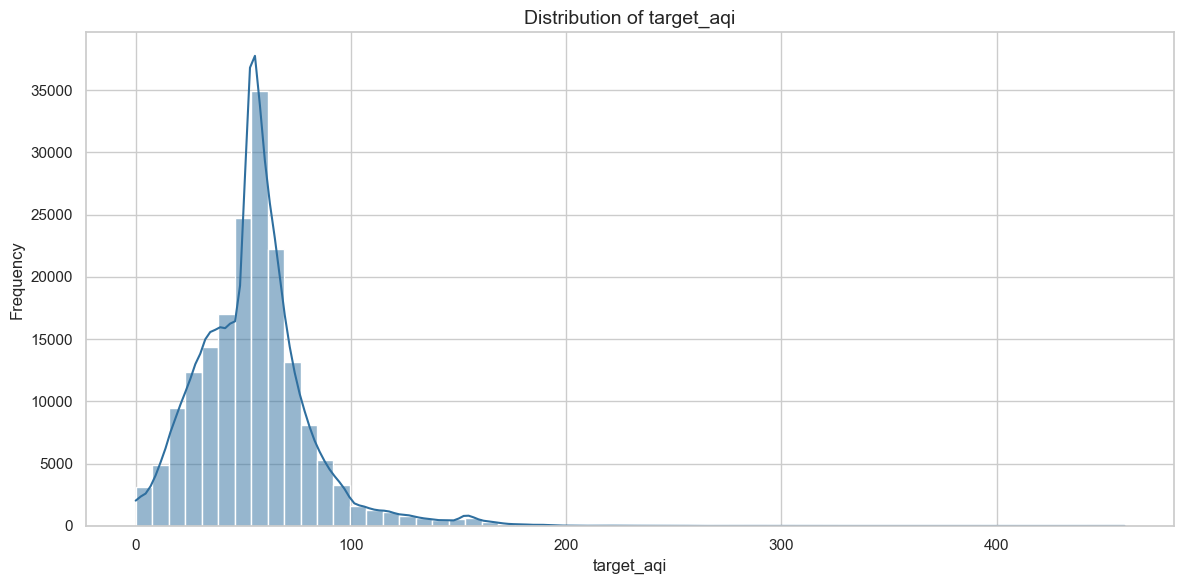

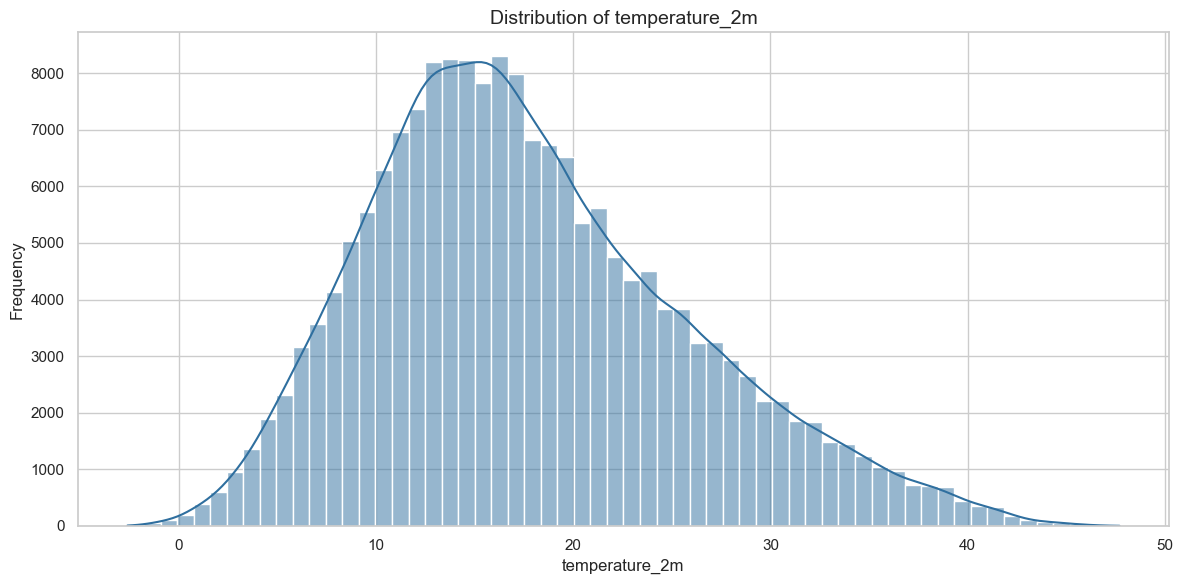

In [5]:
for col in [target_col, "pm2_5", "temperature_2m"]:
    if col in numeric_df.columns:
        plt.figure(figsize=(12, 6))
        sns.histplot(df[col].dropna(), bins=60, kde=True, color="#2f6f9f")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

## 6. Boxplots and Outlier Structure

Boxplots provide a compact view of spread and high-end observations. In AQI forecasting, upper-tail behavior is especially important because high AQI events carry greater environmental and public-health relevance.

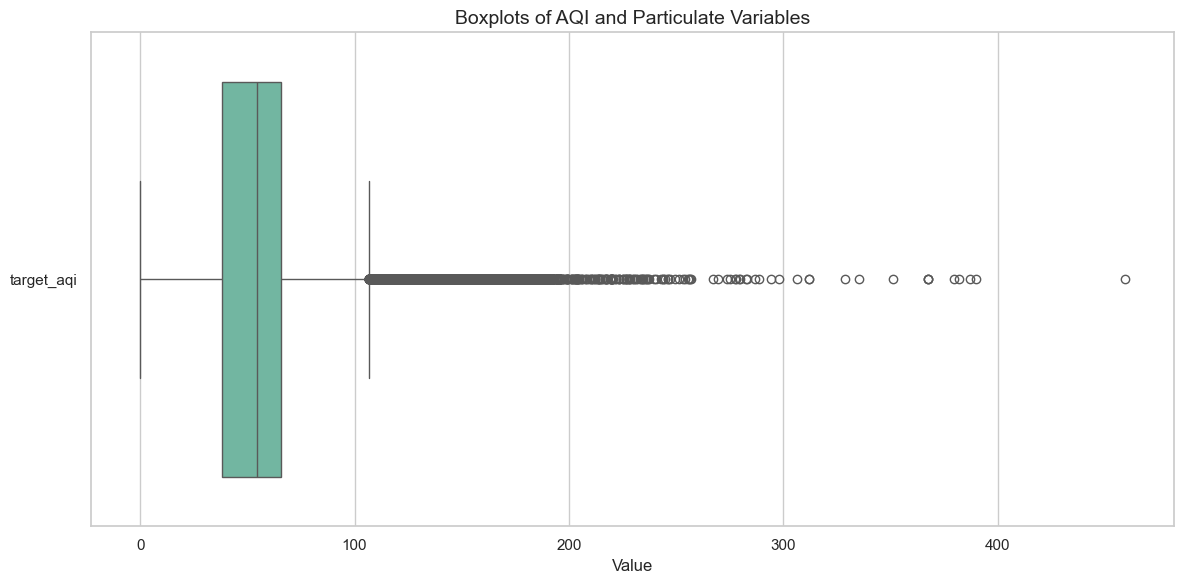

In [6]:
box_cols = [c for c in [target_col, "pm2_5", "pm10"] if c in numeric_df.columns]
if box_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[box_cols], orient="h", palette="Set2")
    plt.title("Boxplots of AQI and Particulate Variables")
    plt.xlabel("Value")
    plt.tight_layout()
    plt.show()

## 7. Bivariate Relationships

Scatterplots compare AQI with major pollutants and meteorological variables. Strong pollutant relationships support proxy-based forecasting, while meteorological relationships may be nonlinear and event-dependent.

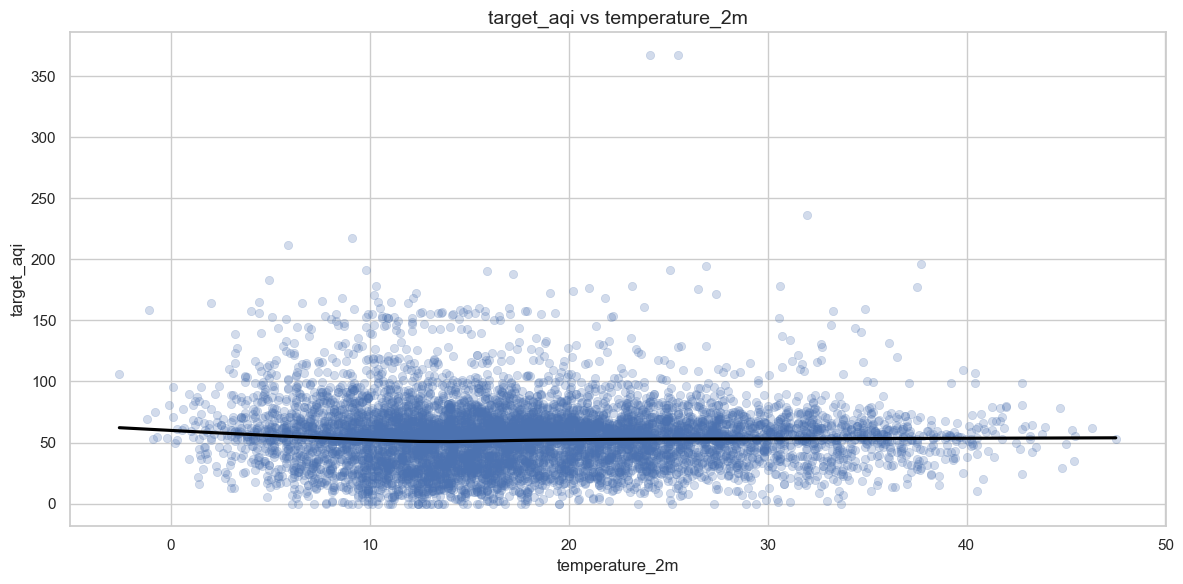

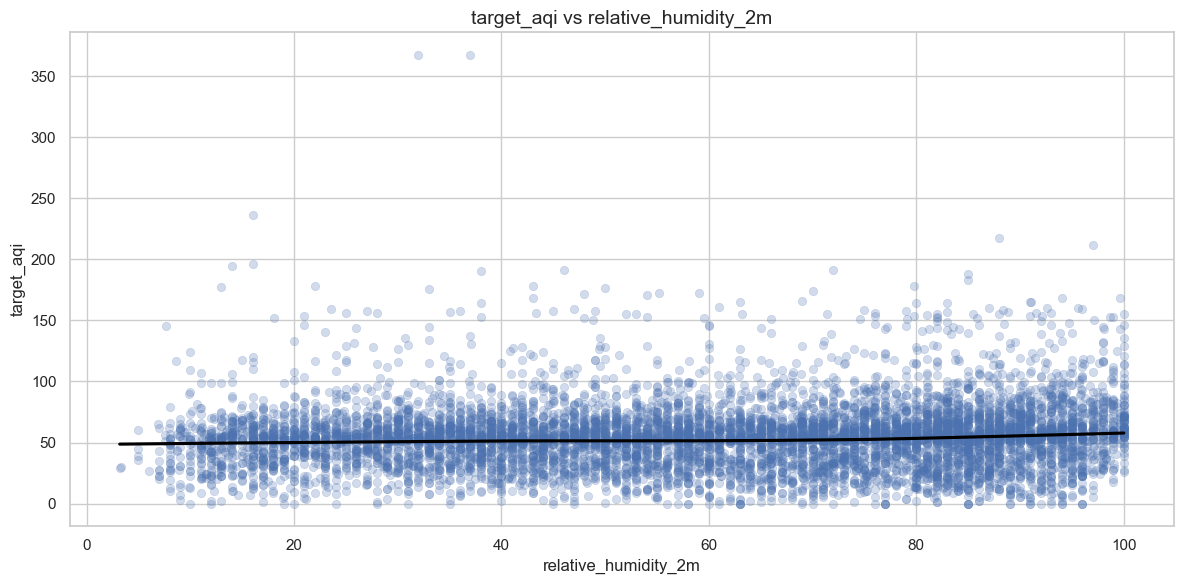

In [7]:
scatter_cols = [c for c in ["pm2_5", "temperature_2m", "relative_humidity_2m"] if c in numeric_df.columns]
for col in scatter_cols:
    sample = df[[target_col, col]].dropna().sample(min(8000, df[[target_col, col]].dropna().shape[0]), random_state=42)
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=sample, x=col, y=target_col, alpha=0.25, edgecolor=None)
    sns.regplot(data=sample, x=col, y=target_col, scatter=False, color="black", lowess=True)
    plt.title(f"{target_col} vs {col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

The heatmap is intentionally labeled in English for direct use in the paper. Correlation does not establish causality, but it helps identify dominant associations and redundant predictors.

In [ ]:
# Select major numeric columns for correlation analysis.
corr_cols = [c for c in [target_col, "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "ozone", "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure"] if c in numeric_df.columns]
if len(corr_cols) < 5:
    corr_cols = numeric_df.columns[:min(15, numeric_df.shape[1])].tolist()

# Compute correlation matrix and visualize.
corr_matrix = numeric_df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix of Major Variables")
plt.tight_layout()

# Save the heatmap.
correlation_heatmap_path = PLOTS_DIR / "eda" / "03_correlation_heatmap.png"
correlation_heatmap_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(correlation_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Correlation heatmap saved to: {correlation_heatmap_path}")


data\plots\eda\03_correlation_heatmap.png


## 9. Pairplot of Major Variables

The pairplot provides a compact visual summary of joint distributions. A sample is used to keep rendering fast and readable.

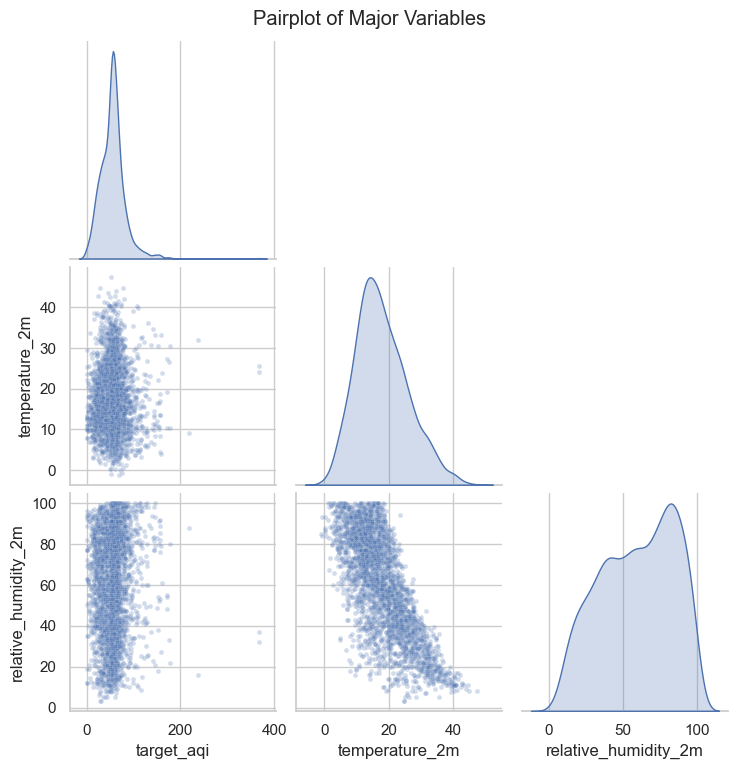

In [32]:
pair_cols = [c for c in [target_col, "pm2_5", "pm10", "temperature_2m", "relative_humidity_2m"] if c in numeric_df.columns]
if len(pair_cols) >= 3:
    pair_sample = df[pair_cols].dropna().sample(min(3000, df[pair_cols].dropna().shape[0]), random_state=42)
    sns.pairplot(pair_sample, diag_kind="kde", corner=True, plot_kws={"alpha": 0.25, "s": 12})
    plt.suptitle("Pairplot of Major Variables", y=1.02)
    plt.show()

## 10. Time-Series Analysis

Time-series plots show long-term AQI, pollutant, and meteorological variation. Rolling averages smooth hourly volatility and reveal medium-term seasonal patterns.

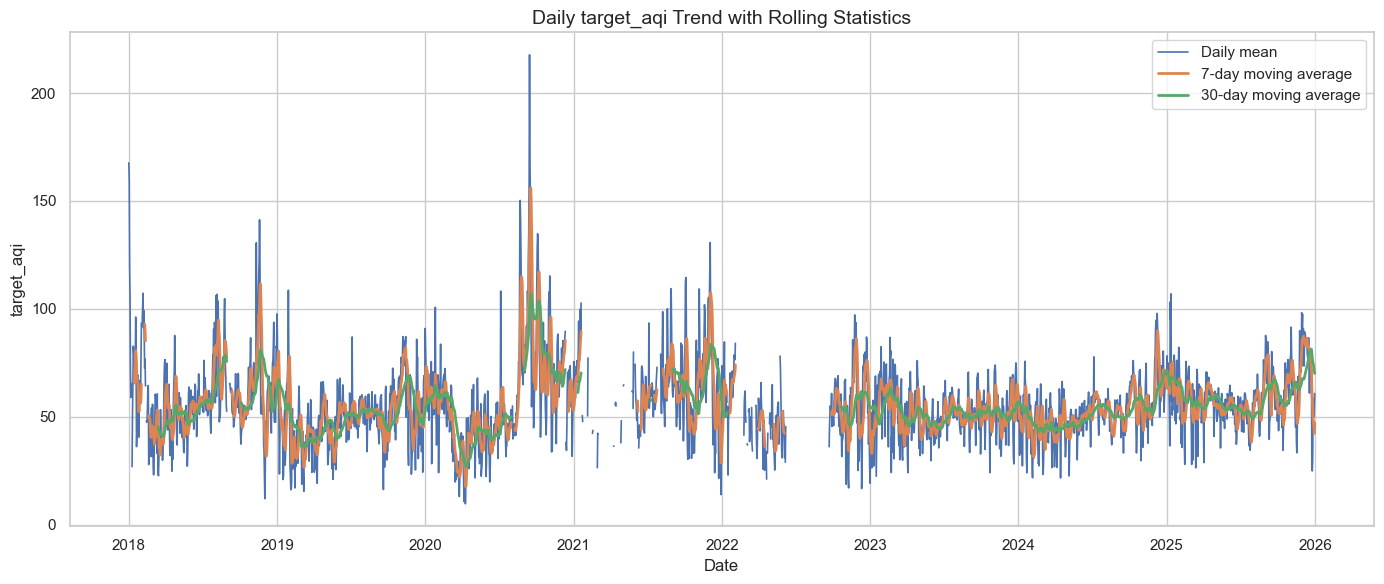

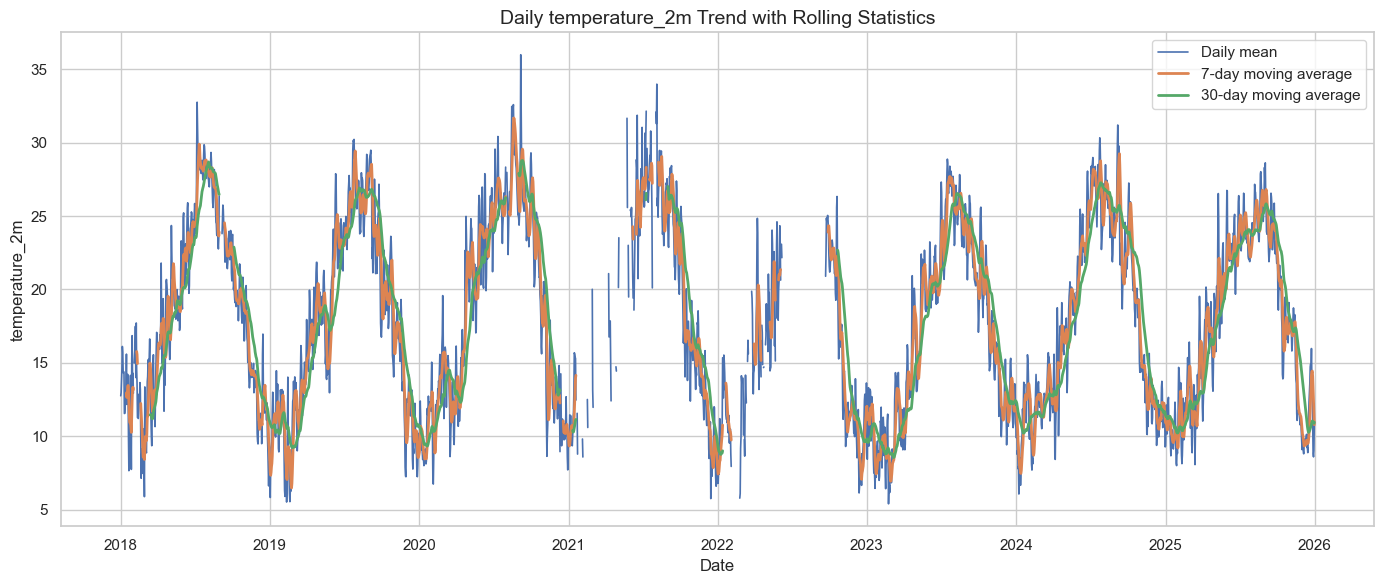

In [33]:
plot_cols = [c for c in [target_col, "pm2_5", "temperature_2m"] if c in numeric_df.columns]
for col in plot_cols:
    daily = df[col].resample("D").mean()
    plt.figure(figsize=(14, 6))
    plt.plot(daily.index, daily.values, linewidth=1.2, label="Daily mean")
    plt.plot(daily.rolling(7).mean(), linewidth=2, label="7-day moving average")
    plt.plot(daily.rolling(30).mean(), linewidth=2, label="30-day moving average")
    plt.title(f"Daily {col} Trend with Rolling Statistics")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 11. AQI Category Timeline

US AQI categories make the target easier to interpret environmentally. The line color changes by AQI breakpoint, which is useful for paper figures and presentations.

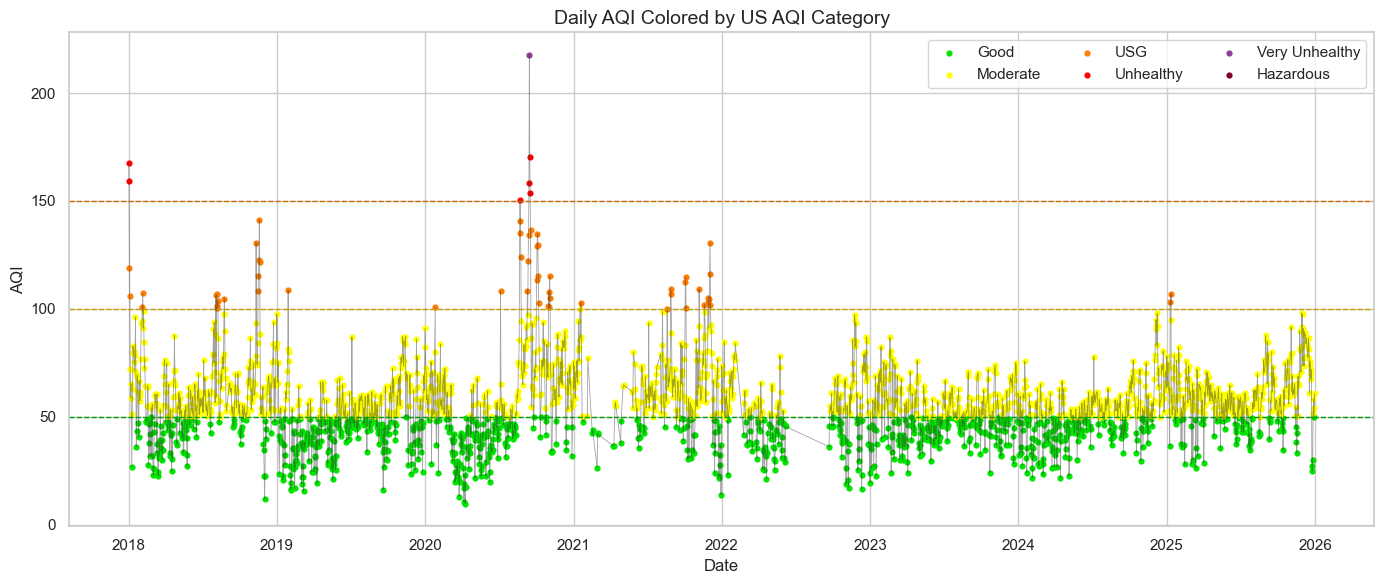

In [34]:
def aqi_category(value):
    if value <= 50:
        return "Good"
    if value <= 100:
        return "Moderate"
    if value <= 150:
        return "USG"
    if value <= 200:
        return "Unhealthy"
    if value <= 300:
        return "Very Unhealthy"
    return "Hazardous"

category_colors = {
    "Good": "#00e400",
    "Moderate": "#ffff00",
    "USG": "#ff7e00",
    "Unhealthy": "#ff0000",
    "Very Unhealthy": "#8f3f97",
    "Hazardous": "#7e0023",
}

daily_aqi = df[target_col].resample("D").mean().dropna().to_frame("AQI")
daily_aqi["Category"] = daily_aqi["AQI"].map(aqi_category)

plt.figure(figsize=(14, 6))
for category, color in category_colors.items():
    part = daily_aqi[daily_aqi["Category"] == category]
    plt.scatter(part.index, part["AQI"], s=12, color=color, label=category)
plt.plot(daily_aqi.index, daily_aqi["AQI"], color="#333333", linewidth=0.6, alpha=0.45)
plt.axhline(50, color="#00a000", linestyle="--", linewidth=1)
plt.axhline(100, color="#c9a000", linestyle="--", linewidth=1)
plt.axhline(150, color="#d56b00", linestyle="--", linewidth=1)
plt.title("Daily AQI Colored by US AQI Category")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend(ncol=3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_aqi_category_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Seasonal Analysis

Seasonal grouping examines whether AQI distributions vary by month, season, and day of week. These patterns support the use of cyclic time features in forecasting models.

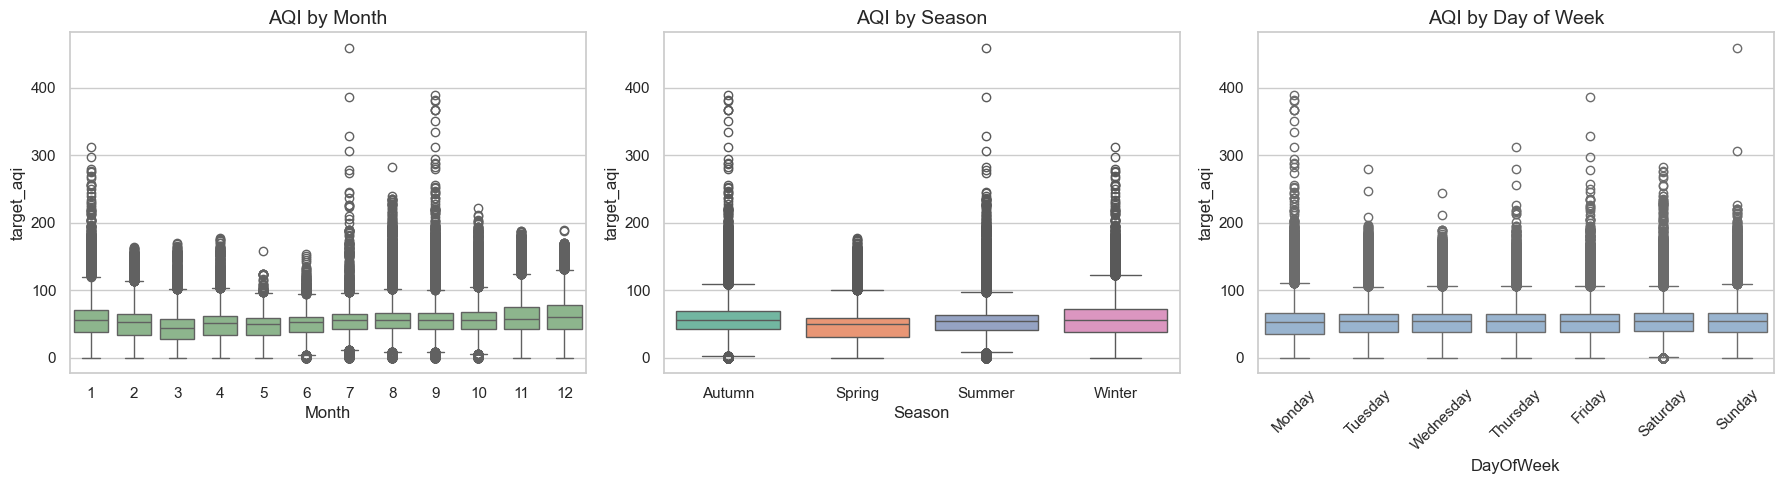

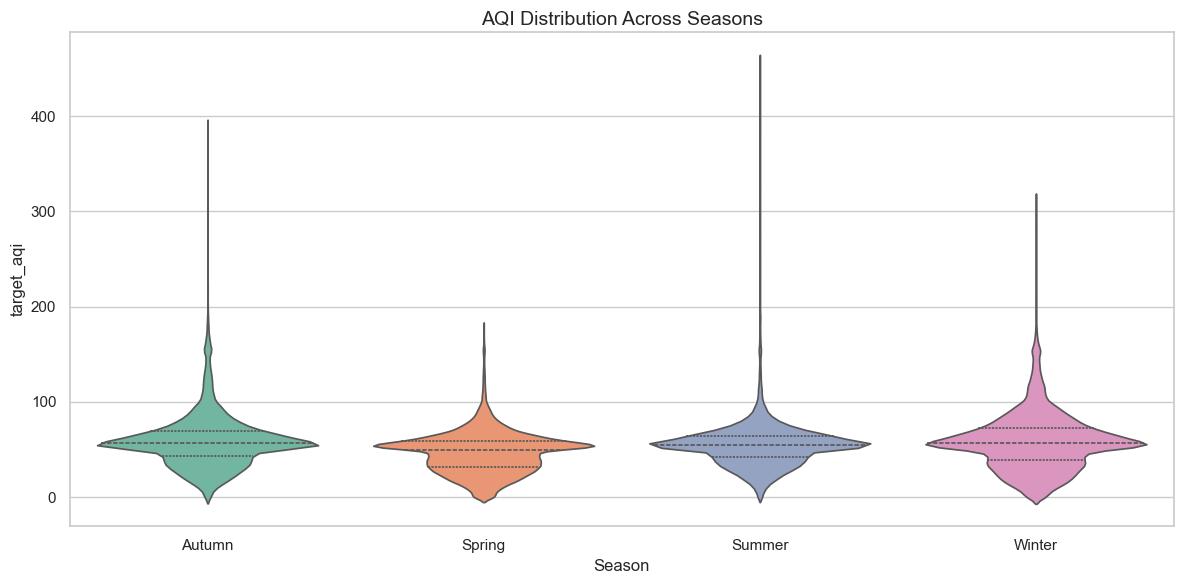

In [35]:
season_df = df[[target_col]].copy()
season_df["Month"] = season_df.index.month
season_df["DayOfWeek"] = season_df.index.day_name()
season_df["Season"] = pd.cut(
    season_df["Month"],
    bins=[0, 2, 5, 8, 11, 12],
    labels=["Winter", "Spring", "Summer", "Autumn", "Winter"],
    ordered=False,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=season_df, x="Month", y=target_col, ax=axes[0], color="#86bc86")
axes[0].set_title("AQI by Month")
sns.boxplot(data=season_df, x="Season", y=target_col, ax=axes[1], palette="Set2")
axes[1].set_title("AQI by Season")
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=season_df, x="DayOfWeek", y=target_col, order=order, ax=axes[2], color="#90b4d8")
axes[2].set_title("AQI by Day of Week")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=season_df, x="Season", y=target_col, palette="Set2", inner="quartile")
plt.title("AQI Distribution Across Seasons")
plt.tight_layout()
plt.show()

## 13. Vapor Pressure Deficit (VPD) Diagnostic

The paper includes vapor pressure deficit (VPD) as an engineered dryness feature, but VPD is not stored directly in the model-ready CSV. This section recomputes VPD from temperature and relative humidity so the EDA notebook documents the feature used later by the modeling pipeline.

VPD is interpreted as atmospheric moisture demand. Higher VPD indicates drier air, which can be relevant for smoke persistence, vegetation dryness, and particle accumulation contexts. This diagnostic is descriptive: it supports feature motivation, but it does not prove that VPD independently improves forecasting accuracy without a formal ablation study.


In [ ]:
def vapor_pressure_deficit_kpa(temperature_c, relative_humidity_pct):
    """Compute vapor pressure deficit in kPa from temperature and relative humidity."""
    saturation_vapor_pressure = 0.6108 * np.exp((17.27 * temperature_c) / (temperature_c + 237.3))
    actual_vapor_pressure = saturation_vapor_pressure * (relative_humidity_pct / 100.0)
    return (saturation_vapor_pressure - actual_vapor_pressure).clip(lower=0)

required_vpd_cols = [target_col, "temperature_2m", "relative_humidity_2m"]
missing_vpd_cols = [col for col in required_vpd_cols if col not in df.columns]
if missing_vpd_cols:
    raise ValueError(f"Missing columns required for VPD diagnostic: {missing_vpd_cols}")

df["vpd_kpa"] = vapor_pressure_deficit_kpa(df["temperature_2m"], df["relative_humidity_2m"])

print("VPD diagnostic summary")
display(
    df[["vpd_kpa", target_col, "temperature_2m", "relative_humidity_2m"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .round(3)
)

vpd_corr_cols = [
    target_col,
    "vpd_kpa",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "rain",
]
vpd_corr_cols = [col for col in vpd_corr_cols if col in df.columns]

print("Correlation with target AQI, including VPD")
vpd_corr = (
    df[vpd_corr_cols]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .round(4)
)
display(vpd_corr.to_frame("correlation_with_target_aqi"))

vpd_quartile_summary = (
    df.assign(vpd_quartile=pd.qcut(df["vpd_kpa"], q=4, duplicates="drop"))
    .groupby("vpd_quartile", observed=True)
    .agg(
        records=(target_col, "size"),
        mean_vpd_kpa=("vpd_kpa", "mean"),
        mean_target_aqi=(target_col, "mean"),
        p95_target_aqi=(target_col, lambda s: s.quantile(0.95)),
    )
    .round(3)
)

print("Target AQI by VPD quartile")
display(vpd_quartile_summary)

monthly_vpd = (
    df.assign(Month=df.index.month)
    .groupby("Month")
    .agg(
        mean_target_aqi=(target_col, "mean"),
        mean_vpd_kpa=("vpd_kpa", "mean"),
        p95_vpd_kpa=("vpd_kpa", lambda s: s.quantile(0.95)),
    )
    .round(3)
)

display(monthly_vpd)

eda_plots_dir = PLOTS_DIR / "eda"
eda_plots_dir.mkdir(parents=True, exist_ok=True)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly_vpd.index, monthly_vpd["mean_target_aqi"], marker="o", color="#2f6f9f", label="Mean target AQI")
ax1.set_xlabel("Month")
ax1.set_ylabel("Mean target AQI", color="#2f6f9f")
ax1.tick_params(axis="y", labelcolor="#2f6f9f")
ax1.set_xticks(range(1, 13))
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(monthly_vpd.index, monthly_vpd["mean_vpd_kpa"], marker="s", color="#c2410c", label="Mean VPD (kPa)")
ax2.fill_between(monthly_vpd.index, monthly_vpd["mean_vpd_kpa"], color="#fed7aa", alpha=0.25)
ax2.set_ylabel("Mean VPD (kPa)", color="#c2410c")
ax2.tick_params(axis="y", labelcolor="#c2410c")

plt.title("Monthly AQI and Vapor Pressure Deficit")
fig.tight_layout()
vpd_plot_path = eda_plots_dir / "07_vpd_monthly_diagnostic.png"
plt.savefig(vpd_plot_path, bbox_inches="tight", dpi=220)
plt.show()
print(f"Saved VPD diagnostic plot to: {vpd_plot_path}")


## 13. Extreme AQI Event Analysis (99th Percentile)

This section analyzes rare high-impact air pollution episodes in `california_aqi_model_ready.csv`. Following a Climate Data Scientist framing, an **Extreme AQI Event** is defined as an hourly record where `target_aqi` is greater than the empirical 99th percentile. The analysis counts extreme-event hours by year and month, then checks whether the peak months align with California late-summer to autumn wildfire-season pollution patterns.


99th percentile threshold of target_aqi: 151.84
Extreme AQI Events (> P99): 1,802 hourly records
Share of dataset: 0.99%
Extreme-event time range: 2018-01-01 12:00:00 to 2025-12-23 10:00:00


,count,mean,std,min,25%,50%,75%,max
target_aqi,1802.0,169.721,26.774,151.911,155.486,161.375,173.261,459.363



Extreme-event hours by year:


,extreme_hours
year,
2018,294
2019,36
2020,483
2021,249
2022,54
2023,216
2024,172
2025,298



Extreme-event hours by month:


,extreme_hours
month,
1,293
2,41
3,41
4,52
5,1
6,1
7,67
8,247
9,286



Top year-month peaks:


,year,month,extreme_hours
0,2020,M09,217
1,2018,M11,124
2,2020,M08,106
3,2025,M01,96
4,2020,M10,94
5,2018,M01,85
6,2024,M12,83
7,2021,M10,72
8,2025,M09,60
9,2024,M10,59


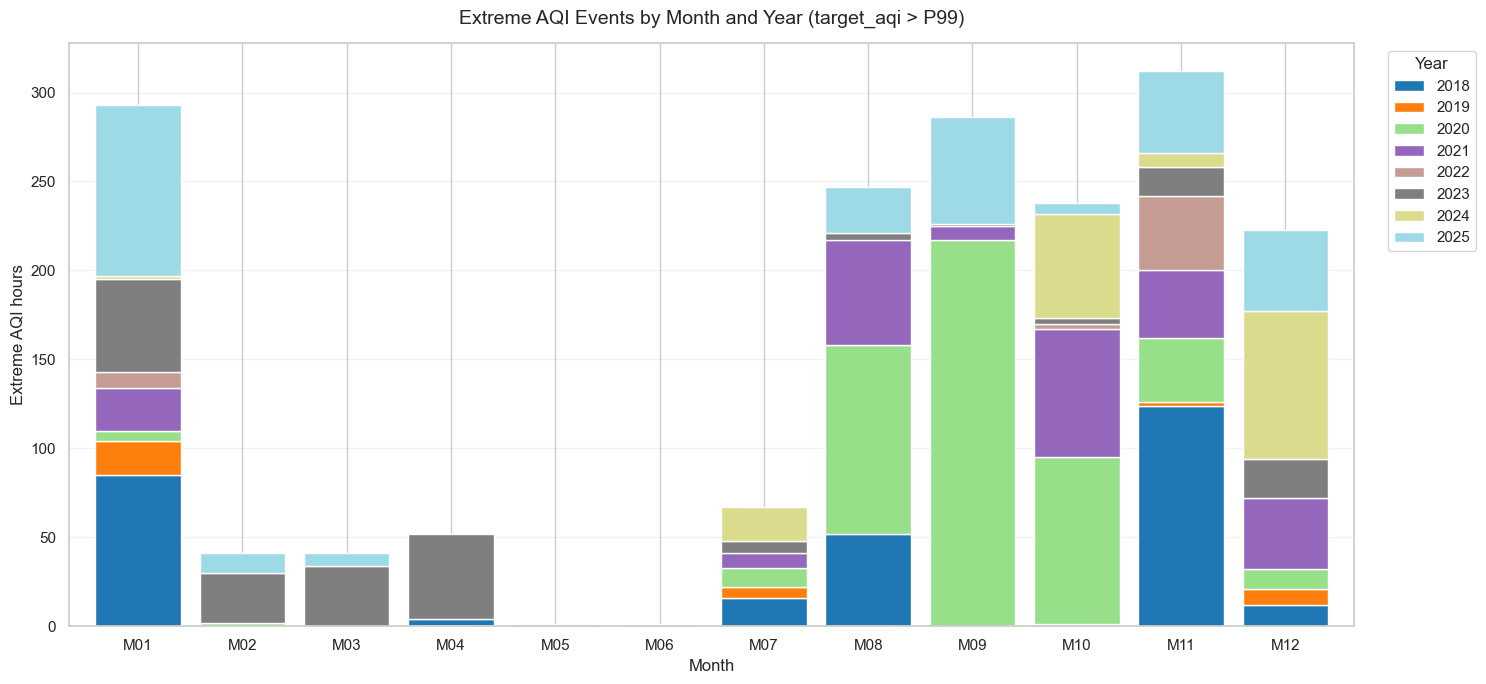

Saved stacked bar chart to: c:\FPT\SU2026\DAP391m\Project\data\plots\eda\05_extreme_aqi_events_stacked_month_year.png


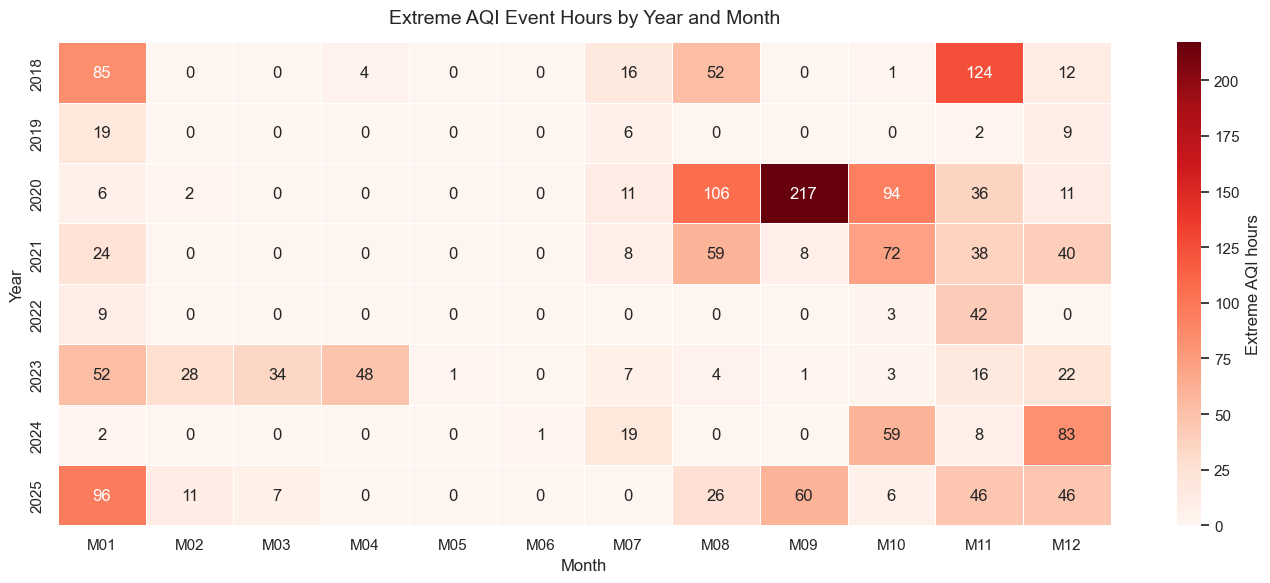

Saved heatmap to: c:\FPT\SU2026\DAP391m\Project\data\plots\eda\06_extreme_aqi_events_heatmap_year_month.png

Extreme-event concentration by station:


,extreme_hours,mean_extreme_aqi,max_extreme_aqi
station_name,,,
Fresno - Garland,1018,171.87,389.84
Los Angeles - Open-Meteo,496,164.53,311.96
Los Angeles - N. Main,201,168.46,459.36
Fresno - Open-Meteo,87,177.10,253.32



Climate Data Scientist notes:
- The year with the most Extreme AQI hours is 2020, with 483 hours above the P99 threshold.
- The months with the most extreme events are: M11 (312 hours), M01 (293 hours), M09 (286 hours)
- August-October accounts for 771/1,802 extreme hours (42.8%).
- A high August-October share suggests that pollution peaks cluster in late summer to early autumn, which is consistent with California wildfire-season smoke impacts.
- Important caveat: this analysis identifies timing and concentration of extreme AQI, not causality. To attribute events to wildfires, join wildfire perimeter, smoke plume, wind trajectory, or AOD data.


In [36]:
from IPython.display import display

# Read the model-ready dataset required for Extreme Event Analysis.
EXTREME_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "california_aqi_model_ready.csv"
EXTREME_PLOTS_DIR = PLOTS_DIR / "eda"
EXTREME_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

extreme_df = pd.read_csv(EXTREME_DATA_PATH)

# Standardize time and validate the core columns used for year-month event counts.
if "time" in extreme_df.columns:
    extreme_df["time"] = pd.to_datetime(extreme_df["time"], errors="coerce")

required_cols = ["target_aqi", "year", "month"]
missing_cols = [col for col in required_cols if col not in extreme_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Extreme Event Analysis: {missing_cols}")

for col in required_cols:
    extreme_df[col] = pd.to_numeric(extreme_df[col], errors="coerce")

extreme_df = extreme_df.dropna(subset=required_cols).copy()
extreme_df["year"] = extreme_df["year"].astype(int)
extreme_df["month"] = extreme_df["month"].astype(int)

# 1. Compute the 99th percentile threshold and keep only hourly records above it.
aqi_p99_threshold = extreme_df["target_aqi"].quantile(0.99)
extreme_events = extreme_df[extreme_df["target_aqi"] > aqi_p99_threshold].copy()

print(f"99th percentile threshold of target_aqi: {aqi_p99_threshold:.2f}")
print(f"Extreme AQI Events (> P99): {len(extreme_events):,} hourly records")
print(f"Share of dataset: {len(extreme_events) / len(extreme_df) * 100:.2f}%")
if "time" in extreme_events.columns and extreme_events["time"].notna().any():
    print(f"Extreme-event time range: {extreme_events['time'].min()} to {extreme_events['time'].max()}")

display(extreme_events[["target_aqi"]].describe().T.round(3))

# 2. Count extreme-event hours by year and by month.
yearly_extreme_counts = (
    extreme_events.groupby("year")
    .size()
    .rename("extreme_hours")
    .to_frame()
    .sort_index()
)

monthly_extreme_counts = (
    extreme_events.groupby("month")
    .size()
    .rename("extreme_hours")
    .reindex(range(1, 13), fill_value=0)
    .to_frame()
)
monthly_extreme_counts.index.name = "month"

extreme_year_month = (
    extreme_events.pivot_table(
        index="year",
        columns="month",
        values="target_aqi",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(columns=range(1, 13), fill_value=0)
    .astype(int)
    .sort_index()
)
extreme_year_month.columns = [f"M{month:02d}" for month in extreme_year_month.columns]

top_year_month_peaks = (
    extreme_year_month.stack()
    .sort_values(ascending=False)
    .head(10)
    .rename("extreme_hours")
    .reset_index()
    .rename(columns={"level_1": "month"})
)

print("\nExtreme-event hours by year:")
display(yearly_extreme_counts)

print("\nExtreme-event hours by month:")
display(monthly_extreme_counts)

print("\nTop year-month peaks:")
display(top_year_month_peaks)

# 3a. Stacked bar chart: monthly extreme-event hours split by year.
stacked_month_year = extreme_year_month.T
fig, ax = plt.subplots(figsize=(15, 7))
stacked_month_year.plot(
    kind="bar",
    stacked=True,
    colormap="tab20",
    width=0.82,
    ax=ax,
)
ax.set_title("Extreme AQI Events by Month and Year (target_aqi > P99)", pad=14)
ax.set_xlabel("Month")
ax.set_ylabel("Extreme AQI hours")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
stacked_path = EXTREME_PLOTS_DIR / "05_extreme_aqi_events_stacked_month_year.png"
plt.savefig(stacked_path, bbox_inches="tight", dpi=220)
plt.show()
print(f"Saved stacked bar chart to: {stacked_path}")

# 3b. Heatmap: easier to identify disaster years and pollution seasons.
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    extreme_year_month,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Extreme AQI hours"},
    ax=ax,
)
ax.set_title("Extreme AQI Event Hours by Year and Month", pad=14)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
heatmap_path = EXTREME_PLOTS_DIR / "06_extreme_aqi_events_heatmap_year_month.png"
plt.savefig(heatmap_path, bbox_inches="tight", dpi=220)
plt.show()
print(f"Saved heatmap to: {heatmap_path}")

# Optional station-level view: where the extreme hours concentrate.
if "station_name" in extreme_events.columns:
    station_extreme_counts = (
        extreme_events.groupby("station_name")
        .agg(
            extreme_hours=("target_aqi", "size"),
            mean_extreme_aqi=("target_aqi", "mean"),
            max_extreme_aqi=("target_aqi", "max"),
        )
        .sort_values("extreme_hours", ascending=False)
        .round(2)
    )
    print("\nExtreme-event concentration by station:")
    display(station_extreme_counts)

# 4. Climate interpretation: check whether August-October dominates the extremes.
month_totals = monthly_extreme_counts["extreme_hours"]
top_months = month_totals.sort_values(ascending=False).head(3)
wildfire_month_labels = ["M08", "M09", "M10"]
wildfire_season_count = extreme_year_month[wildfire_month_labels].to_numpy().sum()
wildfire_season_share = wildfire_season_count / len(extreme_events) * 100 if len(extreme_events) else 0

top_year = yearly_extreme_counts["extreme_hours"].idxmax()
top_year_count = int(yearly_extreme_counts.loc[top_year, "extreme_hours"])

print("\nClimate Data Scientist notes:")
print(
    f"- The year with the most Extreme AQI hours is {top_year}, "
    f"with {top_year_count:,} hours above the P99 threshold."
)
print(
    "- The months with the most extreme events are: "
    + ", ".join([f"M{month:02d} ({int(count):,} hours)" for month, count in top_months.items()])
)
print(
    f"- August-October accounts for {wildfire_season_count:,}/{len(extreme_events):,} "
    f"extreme hours ({wildfire_season_share:.1f}%)."
)

if wildfire_season_share >= 40:
    print(
        "- A high August-October share suggests that pollution peaks cluster in late summer to early autumn, "
        "which is consistent with California wildfire-season smoke impacts."
    )
elif wildfire_season_share >= 25:
    print(
        "- August-October contributes meaningfully to the extremes, so wildfire-season smoke is a plausible driver "
        "that should be tested with external fire or smoke data."
    )
else:
    print(
        "- Extreme events are not dominated by August-October alone; winter inversions, urban emissions, "
        "station location, and meteorological stagnation should also be examined."
    )

print(
    "- Important caveat: this analysis identifies timing and concentration of extreme AQI, not causality. "
    "To attribute events to wildfires, join wildfire perimeter, smoke plume, wind trajectory, or AOD data."
)


## 14. Interactive Plotly Charts

Interactive charts support inspection of long time spans and high-AQI clusters. These plots are useful during analysis, while static exports are preferred for the paper.

In [37]:
daily_plot = daily_aqi.reset_index().rename(columns={daily_aqi.index.name or "index": "Date"})
fig = px.line(daily_plot, x=daily_plot.columns[0], y="AQI", title="Interactive Daily AQI Trend")
fig.show()

if "pm2_5" in df.columns:
    pm_daily = df["pm2_5"].resample("D").mean().reset_index()
    fig = px.line(pm_daily, x=pm_daily.columns[0], y="pm2_5", title="Interactive Daily PM2.5 Trend")
    fig.show()

extreme_daily = daily_aqi[daily_aqi["AQI"] >= daily_aqi["AQI"].quantile(0.95)].reset_index()
fig = px.scatter(extreme_daily, x=extreme_daily.columns[0], y="AQI", color="Category", title="Interactive Extreme AQI Timeline")
fig.show()

## 15. Outlier Detection

Two classical methods are used: IQR and Z-score. These are diagnostic tools, not automatic deletion rules. In environmental forecasting, extreme values may represent important high-risk events rather than errors.

IQR outliers: 6,654
Z-score outliers: 3,007


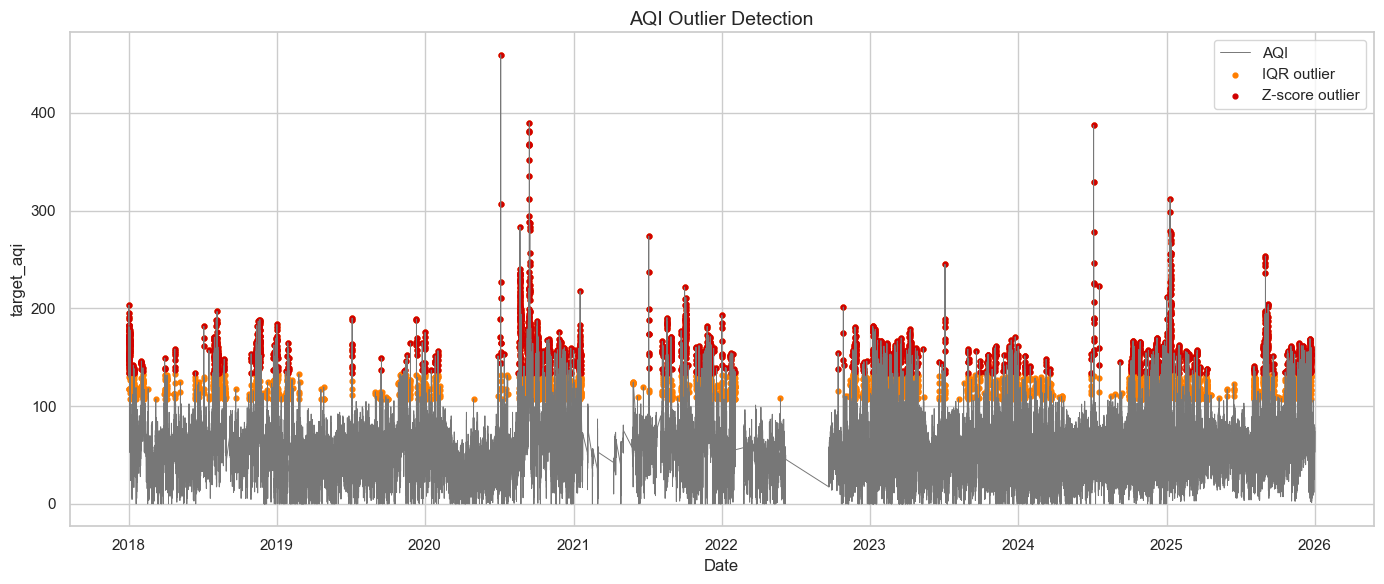

In [38]:
y = df[target_col].dropna()
q1, q3 = y.quantile([0.25, 0.75])
iqr = q3 - q1
iqr_mask = (y < q1 - 1.5 * iqr) | (y > q3 + 1.5 * iqr)
z = np.abs(stats.zscore(y))
z_mask = z > 3

print(f"IQR outliers: {iqr_mask.sum():,}")
print(f"Z-score outliers: {z_mask.sum():,}")

plt.figure(figsize=(14, 6))
plt.plot(y.index, y.values, color="#777777", linewidth=0.7, label="AQI")
plt.scatter(y.index[iqr_mask], y[iqr_mask], color="#ff7e00", s=12, label="IQR outlier")
plt.scatter(y.index[z_mask], y[z_mask], color="#d00000", s=12, label="Z-score outlier")
plt.title("AQI Outlier Detection")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()

## 16. Stationarity Investigation

ADF and KPSS tests provide complementary evidence about stationarity. AQI time series often contain persistence, seasonality, and regime changes, so these tests should be interpreted together with visual diagnostics.

ADF statistic: -6.0514, p-value: 1.275e-07
KPSS statistic: 0.1751, p-value: 0.1


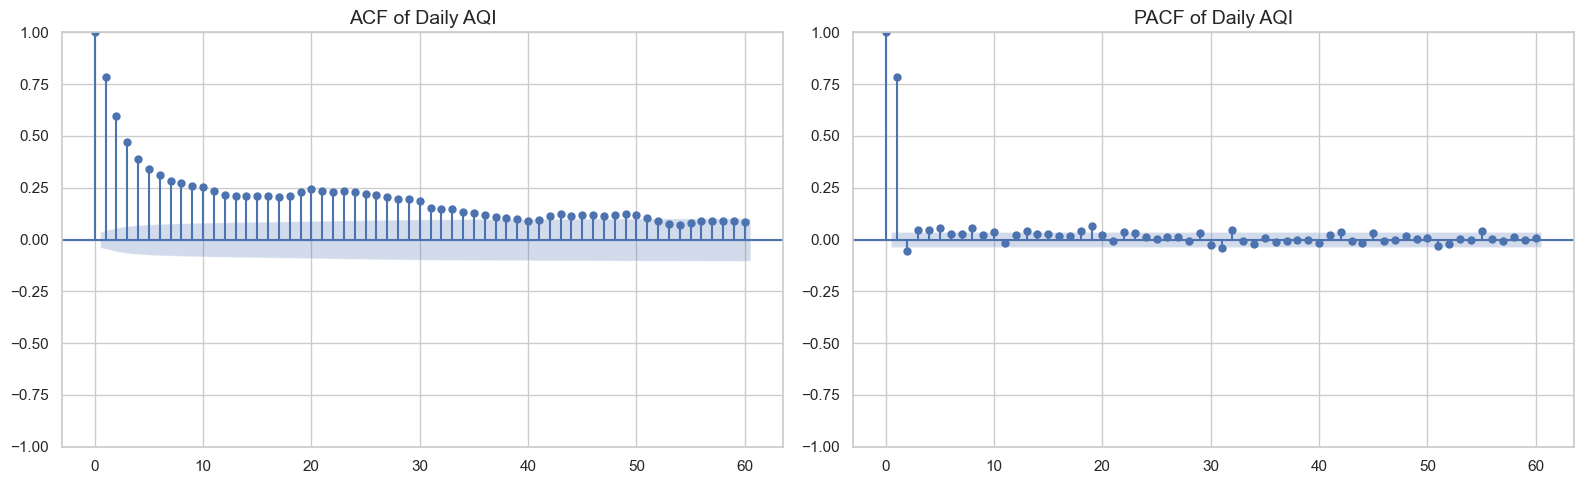

In [39]:
# Use daily means to keep tests computationally stable and interpretable.
daily_series = df[target_col].resample("D").mean().dropna()

adf_stat, adf_p, *_ = adfuller(daily_series)
kpss_stat, kpss_p, *_ = kpss(daily_series, regression="c", nlags="auto")

print(f"ADF statistic: {adf_stat:.4f}, p-value: {adf_p:.4g}")
print(f"KPSS statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(daily_series, lags=60, ax=axes[0])
axes[0].set_title("ACF of Daily AQI")
plot_pacf(daily_series, lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Daily AQI")
plt.tight_layout()
plt.show()

## 17. Feature Engineering Inspection

Lag and rolling features are inspected only if they exist in the dataset. Their correlation with the target helps explain the difference between exogenous-only and target-history experiments.

In [40]:
lag_patterns = ["lag", "rolling", "roll"]
lag_cols = [c for c in numeric_df.columns if any(p in c.lower() for p in lag_patterns)]

if lag_cols:
    corr_with_target = numeric_df[lag_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
    display(corr_with_target.head(20).to_frame("Correlation_with_target"))
    plt.figure(figsize=(12, 7))
    corr_with_target.head(20).sort_values().plot(kind="barh", color="#4c78a8")
    plt.title("Top Lag/Rolling Feature Correlations with Target AQI")
    plt.xlabel("Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("No lag or rolling feature columns detected in the current dataset.")

No lag or rolling feature columns detected in the current dataset.


## 18. Readiness for Forecasting Models

The finalized modeling protocol uses a chronological split: training from 2018-2023, validation in 2024, and independent testing in 2025. Feature scaling must be fitted only on the training split. Lag and rolling target-history features must be generated with safe padding so that validation and test rows never use future target information.

In [41]:
train = df.loc[:"2023-12-31"]
val = df.loc["2024-01-01":"2024-12-31"]
test = df.loc["2025-01-01":"2025-12-31"]

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train), len(val), len(test)],
    "Start": [train.index.min(), val.index.min(), test.index.min()],
    "End": [train.index.max(), val.index.max(), test.index.max()],
})
display(split_summary)

checks = pd.DataFrame({
    "Check": [
        "Chronological order preserved",
        "Validation starts after training",
        "Test starts after validation",
        "Scaler fitted only on training data",
        "Safe padding required for lag/rolling features",
        "Target-history ablation supported",
    ],
    "Status": [
        df.index.is_monotonic_increasing,
        train.index.max() < val.index.min(),
        val.index.max() < test.index.min(),
        "Implemented in modeling script",
        "Implemented in modeling script",
        "use_target_history=True/False",
    ]
})
display(checks)

,Split,Rows,Start,End
0,Train,111093,2018-01-01 12:00:00,2023-12-31 23:00:00
1,Validation,43732,2024-01-01 00:00:00,2024-12-31 23:00:00
2,Test,26297,2025-01-01 00:00:00,2025-12-31 23:00:00


,Check,Status
0,Chronological order preserved,True
1,Validation starts after training,True
2,Test starts after validation,True
3,Scaler fitted only on training data,Implemented in modeling script
4,Safe padding required for lag/rolling features,Implemented in modeling script
5,Target-history ablation supported,use_target_history=True/False


## 19. Final Insights

The current dataset supports a reproducible non-leakage forecasting study through a fixed 2018-2025 chronological panel. AQI is right-skewed, high-AQI observations are rare, and scenario-specific evaluation is necessary because aggregate metrics can hide model behavior in the upper tail. Pollutant and meteorological variables provide meaningful exogenous signal, while lag and rolling features must be handled carefully to avoid temporal leakage. For modeling, tree-boosting methods are expected to perform strongly on nonlinear interactions, Ridge provides a transparent linear baseline, Random Forest offers a robust bagging baseline, and LSTM-24h tests whether sequential daily structure improves forecasting beyond tabular learning.